# LAB02 - Clasificacion de Malware

Implementacion del laboratorio con dos modelos:

1. Modelo 1: TF-IDF + SVM
2. Modelo 2: Embeddings de Gemini + red neuronal (MLP)

## 1) Imports

In [24]:
import os
import json
import time
import random
import warnings
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## 2) Carga y preprocesamiento

In [25]:
DATA_PATH = 'MalBehavD-V1-dataset.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f'No se encontro el archivo: {DATA_PATH}')

df = pd.read_csv(DATA_PATH)
print('Shape original:', df.shape)

seq_cols = [c for c in df.columns if c not in ['sha256', 'labels']]

api_sequences = (
    df[seq_cols]
    .astype(str)
    .replace({'nan': '', 'None': ''})
    .apply(lambda row: [x for x in row.tolist() if x and x != ''], axis=1)
)

texts = api_sequences.apply(lambda toks: ' '.join(toks))
y = df['labels'].astype(int).values

print('Muestras totales:', len(df))
print('Distribucion de clases:', pd.Series(y).value_counts().to_dict())
print('Longitud promedio secuencia:', int(np.mean([len(x) for x in api_sequences])))
print('Longitud maxima secuencia:', int(np.max([len(x) for x in api_sequences])))


Shape original: (2570, 177)
Muestras totales: 2570
Distribucion de clases: {0: 1285, 1: 1285}
Longitud promedio secuencia: 43
Longitud maxima secuencia: 175


## 3) Train/Test split

In [26]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

print('Train:', len(X_train_text), '| Test:', len(X_test_text))


Train: 2056 | Test: 514


## 4) Modelo 1 - TF-IDF + SVM

In [27]:
svm_clf = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000)),
    ('svm', LinearSVC(class_weight='balanced', random_state=SEED)),
])

svm_clf.fit(X_train_text, y_train)
svm_pred = svm_clf.predict(X_test_text)

acc = accuracy_score(y_test, svm_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, svm_pred, average='binary', zero_division=0)

print('=== MODELO 1: TF-IDF + SVM ===')
print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1-score : {f1:.4f}')
print('')
print(classification_report(y_test, svm_pred, digits=4))


=== MODELO 1: TF-IDF + SVM ===
Accuracy : 0.9591
Precision: 0.9646
Recall   : 0.9533
F1-score : 0.9589

              precision    recall  f1-score   support

           0     0.9538    0.9650    0.9594       257
           1     0.9646    0.9533    0.9589       257

    accuracy                         0.9591       514
   macro avg     0.9592    0.9591    0.9591       514
weighted avg     0.9592    0.9591    0.9591       514



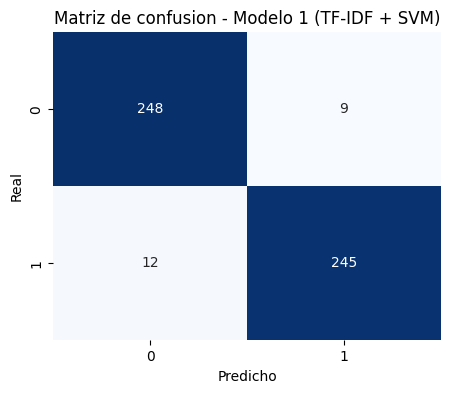

In [28]:
cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de confusion - Modelo 1 (TF-IDF + SVM)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()


## 5) Modelo 2 - Gemini embeddings + red neuronal

In [ ]:
# estas dependencias se necesitan instalar. Las podes correr aqui o en la consola
# !pip install google-genai -q
# !pip install tensorflow -q

SDK_AVAILABLE = True
TF_AVAILABLE = True

try:
    from google import genai
except Exception as e:
    SDK_AVAILABLE = False
    print('google-genai no disponible:', e)

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, load_model
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
    tf.random.set_seed(SEED)
except Exception as e:
    TF_AVAILABLE = False
    print('TensorFlow no disponible:', e)


In [ ]:
if SDK_AVAILABLE:
    try:
        client = genai.Client(api_key="API_KEY")
        print('Cliente Gemini inicializado correctamente.')
    except Exception as e:
        client = None
        print('No se pudo inicializar genai.Client():', e)
else:
    client = None


Cliente Gemini inicializado correctamente.


In [31]:
def _embedding_to_vector(emb_obj):
    if emb_obj is None:
        return None

    if hasattr(emb_obj, 'values'):
        vals = emb_obj.values
        if vals is not None:
            return np.array(vals, dtype=np.float32)

    if isinstance(emb_obj, dict):
        if 'values' in emb_obj:
            return np.array(emb_obj['values'], dtype=np.float32)
        if 'embedding' in emb_obj and isinstance(emb_obj['embedding'], dict) and 'values' in emb_obj['embedding']:
            return np.array(emb_obj['embedding']['values'], dtype=np.float32)

    return None


def _extract_retry_seconds(err_msg, default_wait=30):
    m1 = re.search(r'retry in\s+([0-9]+(?:\.[0-9]+)?)s', err_msg, re.IGNORECASE)
    if m1:
        return max(1, int(float(m1.group(1)) + 1))

    m2 = re.search(r"retryDelay[^0-9]*([0-9]+)s", err_msg, re.IGNORECASE)
    if m2:
        return max(1, int(m2.group(1)) + 1)

    return default_wait


def _embed_batch_with_retry(client, batch, model, req_timestamps, requests_per_minute_limit=95, max_retries=8):
    from collections import deque

    def wait_for_rpm_slot():
        while True:
            now = time.time()
            while req_timestamps and (now - req_timestamps[0]) >= 60.0:
                req_timestamps.popleft()
            if len(req_timestamps) < requests_per_minute_limit:
                return
            sleep_s = (60.0 - (now - req_timestamps[0])) + 0.05
            if sleep_s > 0:
                time.sleep(sleep_s)

    attempt = 0
    while True:
        try:
            wait_for_rpm_slot()
            req_timestamps.append(time.time())

            result = client.models.embed_content(model=model, contents=batch)
            emb_list = getattr(result, 'embeddings', None)
            if emb_list is None:
                raise RuntimeError(f'No se encontraron embeddings en la respuesta del SDK. Respuesta: {result}')
            if len(emb_list) != len(batch):
                raise RuntimeError(f'Respuesta incompleta: se esperaban {len(batch)} embeddings y llegaron {len(emb_list)}')

            vecs = []
            for emb in emb_list:
                v = _embedding_to_vector(emb)
                if v is None:
                    raise RuntimeError(f'No se pudo convertir embedding a vector. Embedding: {emb}')
                vecs.append(v)
            return np.vstack(vecs)

        except Exception as e:
            err_msg = str(e)
            attempt += 1
            if '429' in err_msg or 'RESOURCE_EXHAUSTED' in err_msg or 'quota' in err_msg.lower():
                wait_s = _extract_retry_seconds(err_msg, default_wait=35)
            else:
                wait_s = min(10 * attempt, 60)

            if attempt > max_retries:
                raise RuntimeError(f'Fallo permanente al generar embeddings. Ultimo error: {err_msg}')

            print(f'[WARN] API throttle/error. Esperando {wait_s}s... (intento {attempt}/{max_retries})')
            time.sleep(wait_s)


def generate_embeddings_with_checkpoint(
    client,
    texts,
    split_name,
    cache_dir,
    model='gemini-embedding-001',
    batch_size=12,
    requests_per_minute_limit=95,
    max_retries=8,
):
    from collections import deque

    texts = list(texts)
    n = len(texts)
    req_timestamps = deque()

    run_dir = Path(cache_dir) / f'emb_ckpt_{split_name}_n{n}_b{batch_size}'
    chunks_dir = run_dir / 'chunks'
    progress_file = run_dir / 'progress.json'
    final_file = Path(cache_dir) / f'gemini_{split_name}_embeddings_n{n}.npy'

    run_dir.mkdir(parents=True, exist_ok=True)
    chunks_dir.mkdir(parents=True, exist_ok=True)

    if final_file.exists():
        print(f'[{split_name}] embedding final ya existe, cargando cache final...')
        return np.load(final_file)

    if progress_file.exists():
        progress = json.loads(progress_file.read_text(encoding='utf-8'))
        next_idx = int(progress.get('next_idx', 0))
    else:
        next_idx = 0

    print(f'[{split_name}] reanudando desde indice {next_idx}/{n}')

    for start in range(next_idx, n, batch_size):
        end = min(start + batch_size, n)
        chunk_file = chunks_dir / f'chunk_{start:07d}_{end:07d}.npy'

        if chunk_file.exists():
            # Ya calculado previamente
            pass
        else:
            batch = texts[start:end]
            vecs = _embed_batch_with_retry(
                client,
                batch,
                model,
                req_timestamps,
                requests_per_minute_limit=requests_per_minute_limit,
                max_retries=max_retries,
            )
            np.save(chunk_file, vecs)

        progress = {
            'split': split_name,
            'next_idx': end,
            'n_total': n,
            'model': model,
            'batch_size': batch_size,
            'rpm_limit': requests_per_minute_limit,
            'updated_at': time.time(),
        }
        progress_file.write_text(json.dumps(progress, indent=2), encoding='utf-8')

    # Ensamble final
    all_chunks = sorted(chunks_dir.glob('chunk_*.npy'))
    if not all_chunks:
        raise RuntimeError(f'[{split_name}] No hay chunks para ensamblar.')

    mats = [np.load(fp) for fp in all_chunks]
    emb = np.vstack(mats)

    if emb.shape[0] != n:
        raise RuntimeError(f'[{split_name}] mismatch: embeddings={emb.shape[0]} vs n={n}')

    np.save(final_file, emb)
    print(f'[{split_name}] embeddings completos guardados en: {final_file}')
    return emb


In [32]:
CACHE_DIR = Path('cache')
CACHE_DIR.mkdir(exist_ok=True)

# Modo economico para free tier (recomendado para pruebas)
USE_SUBSET_FOR_MODEL2 = True
MAX_TRAIN_SAMPLES_MODEL2 = 300
MAX_TEST_SAMPLES_MODEL2 = 100

# Ajuste fino para limite gratuito (100 RPM)
EMBED_BATCH_SIZE = 12
EMBED_REQUESTS_PER_MIN = 95

if client is not None:
    gemini_model_used = 'gemini-embedding-001'

    if USE_SUBSET_FOR_MODEL2:
        X_train_m2, _, y_train_m2, _ = train_test_split(
            X_train_text,
            y_train,
            train_size=min(MAX_TRAIN_SAMPLES_MODEL2, len(X_train_text)),
            random_state=SEED,
            stratify=y_train,
        )
        X_test_m2, _, y_test_m2, _ = train_test_split(
            X_test_text,
            y_test,
            train_size=min(MAX_TEST_SAMPLES_MODEL2, len(X_test_text)),
            random_state=SEED,
            stratify=y_test,
        )
    else:
        X_train_m2, y_train_m2 = X_train_text.copy(), y_train.copy()
        X_test_m2, y_test_m2 = X_test_text.copy(), y_test.copy()

    train_n = len(X_train_m2)
    test_n = len(X_test_m2)

    print(f'Modelo 2 con train={train_n}, test={test_n}, subset={USE_SUBSET_FOR_MODEL2}')
    print(f'Rate limit: {EMBED_REQUESTS_PER_MIN} RPM | batch={EMBED_BATCH_SIZE}')

    X_train_emb = generate_embeddings_with_checkpoint(
        client,
        X_train_m2.tolist(),
        split_name='train',
        cache_dir=CACHE_DIR,
        model=gemini_model_used,
        batch_size=EMBED_BATCH_SIZE,
        requests_per_minute_limit=EMBED_REQUESTS_PER_MIN,
        max_retries=10,
    )

    X_test_emb = generate_embeddings_with_checkpoint(
        client,
        X_test_m2.tolist(),
        split_name='test',
        cache_dir=CACHE_DIR,
        model=gemini_model_used,
        batch_size=EMBED_BATCH_SIZE,
        requests_per_minute_limit=EMBED_REQUESTS_PER_MIN,
        max_retries=10,
    )

    print('Embeddings listos.')
    print('Modelo Gemini usado:', gemini_model_used)
    print('Shape train:', X_train_emb.shape, '| Shape test:', X_test_emb.shape)


Modelo 2 con train=300, test=100, subset=True
Generando embeddings con SDK de Gemini (modo gradual para free tier)...
[WARN] Error de API en batch 13. Reintentando en 4s... (intento 1/10)
[WARN] Error de API en batch 13. Reintentando en 60s... (intento 2/10)
[WARN] Error de API en batch 25. Reintentando en 45s... (intento 1/10)
[WARN] Error de API en batch 37. Reintentando en 44s... (intento 1/10)
[WARN] Error de API en batch 12. Reintentando en 44s... (intento 1/10)
Embeddings guardados en cache.
Modelo Gemini usado: gemini-embedding-001
Shape train: (300, 3072) | Shape test: (100, 3072)


In [33]:
if TF_AVAILABLE and client is not None:
    MODEL2_CKPT_PATH = CACHE_DIR / 'model2_best.keras'
    MODEL2_LOG_PATH = CACHE_DIR / 'model2_train_log.csv'

    if MODEL2_CKPT_PATH.exists():
        print('Cargando checkpoint previo de Modelo 2...')
        model2 = load_model(MODEL2_CKPT_PATH)
    else:
        model2 = Sequential([
            Dense(256, activation='relu', input_shape=(X_train_emb.shape[1],)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(128, activation='relu'),
            Dropout(0.2),
            Dense(1, activation='sigmoid')
        ])

        model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    model2.summary()

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ckpt_cb = ModelCheckpoint(
        filepath=str(MODEL2_CKPT_PATH),
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    )
    log_cb = CSVLogger(str(MODEL2_LOG_PATH), append=True)

    # Si reanudas otro dia, vuelve a correr esta celda y continuara desde el checkpoint cargado
    history2 = model2.fit(
        X_train_emb,
        y_train_m2,
        validation_split=0.2,
        epochs=25,
        batch_size=32,
        callbacks=[early_stop, ckpt_cb, log_cb],
        verbose=1,
    )

    y_prob2 = model2.predict(X_test_emb).ravel()
    y_pred2 = (y_prob2 >= 0.5).astype(int)

    acc2 = accuracy_score(y_test_m2, y_pred2)
    prec2, rec2, f12, _ = precision_recall_fscore_support(y_test_m2, y_pred2, average='binary', zero_division=0)

    print('=== MODELO 2: GEMINI EMBEDDINGS + MLP ===')
    print('Modelo Gemini:', gemini_model_used)
    print(f'Accuracy : {acc2:.4f}')
    print(f'Precision: {prec2:.4f}')
    print(f'Recall   : {rec2:.4f}')
    print(f'F1-score : {f12:.4f}')
    print('')
    print(classification_report(y_test_m2, y_pred2, digits=4))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,737 (3.13 MB)

 Trainable params: 820,225 (3.13 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8083 - loss: 0.4274 - val_accuracy: 0.8833 - val_loss: 0.6524
Epoch 2/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9292 - loss: 0.1693 - val_accuracy: 0.8833 - val_loss: 0.6208
Epoch 3/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9792 - loss: 0.0865 - val_accuracy: 0.8833 - val_loss: 0.5950
Epoch 4/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9875 - loss: 0.0571 - val_accuracy: 0.8667 - val_loss: 0.5754
Epoch 5/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0332 - val_accuracy: 0.8833 - val_loss: 0.5592
Epoch 6/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9917 - loss: 0.0258 - val_accuracy: 0.8167 - val_loss: 0.5513
Epoch 7/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9958 - loss: 0.0171 - val_accuracy: 0.8000 - val_loss: 0.5403
Epoch 8/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0088 - val_accuracy: 0.7833 - val_loss: 0.5308
Epoch 9

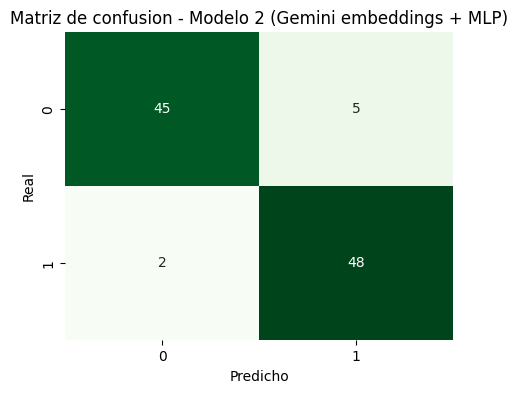

In [34]:
if TF_AVAILABLE and client is not None and 'y_pred2' in globals():
    cm2 = confusion_matrix(y_test_m2, y_pred2)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', cbar=False)
    plt.title('Matriz de confusion - Modelo 2 (Gemini embeddings + MLP)')
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.show()


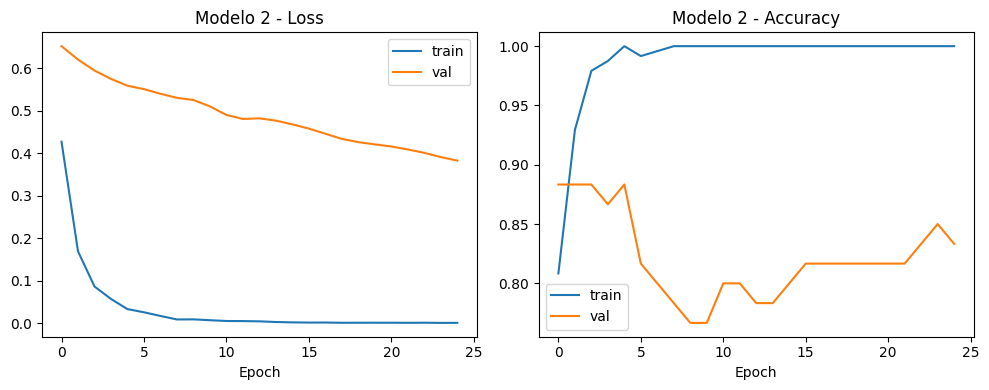

In [35]:
if TF_AVAILABLE and client is not None and 'history2' in globals():
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history2.history['loss'], label='train')
    plt.plot(history2.history['val_loss'], label='val')
    plt.title('Modelo 2 - Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history2.history['accuracy'], label='train')
    plt.plot(history2.history['val_accuracy'], label='val')
    plt.title('Modelo 2 - Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.tight_layout()
    plt.show()


## 6) Comparacion final

In [36]:
results = []

results.append({
    'Modelo': 'TF-IDF + SVM',
    'Eval_Set': 'test completo',
    'Accuracy': accuracy_score(y_test, svm_pred),
    'Precision': precision_recall_fscore_support(y_test, svm_pred, average='binary', zero_division=0)[0],
    'Recall': precision_recall_fscore_support(y_test, svm_pred, average='binary', zero_division=0)[1],
    'F1': precision_recall_fscore_support(y_test, svm_pred, average='binary', zero_division=0)[2],
})

if TF_AVAILABLE and client is not None and 'y_pred2' in globals():
    eval_name = 'subset test' if USE_SUBSET_FOR_MODEL2 else 'test completo'
    results.append({
        'Modelo': 'Gemini embeddings + MLP',
        'Eval_Set': eval_name,
        'Accuracy': accuracy_score(y_test_m2, y_pred2),
        'Precision': precision_recall_fscore_support(y_test_m2, y_pred2, average='binary', zero_division=0)[0],
        'Recall': precision_recall_fscore_support(y_test_m2, y_pred2, average='binary', zero_division=0)[1],
        'F1': precision_recall_fscore_support(y_test_m2, y_pred2, average='binary', zero_division=0)[2],
    })

pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)


,Modelo,Eval_Set,Accuracy,Precision,Recall,F1
0,TF-IDF + SVM,test completo,0.959144,0.964567,0.953307,0.958904
1,Gemini embeddings + MLP,subset test,0.930000,0.905660,0.960000,0.932039
